In [120]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import random
from matplotlib.animation import FuncAnimation, PillowWriter

### Toy problem
#### Create environment and the wound
We create the environment, that is the area around the wound and the area of the wound. 

To create the skin environment, we create a two-dimensional grid ("lattice"). Each part of the grid is a cell (our agents). First we create a grid where all cells are healthy. Then, in the middle of the grid, we replace an rectangular strip of healthy cells with wounded cells.

In [232]:
## creating a grid with all healthy cells
# lattice size
Nx, Ny = 50, 50

# create lattice (0 = empty/wound, 1 = tissue)
lattice = np.ones((Nx, Ny), dtype=int)

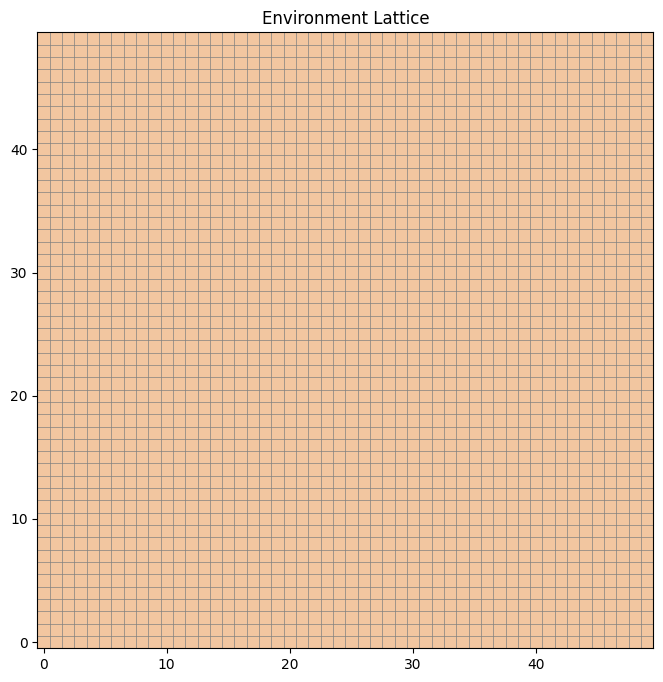

In [233]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(lattice, origin='lower', cmap=ListedColormap(['#f2c6a0']))

# Major ticks (few, readable)
ax.set_xticks(np.arange(0, Nx, 10))
ax.set_yticks(np.arange(0, Ny, 10))

# Minor ticks (for full grid)
ax.set_xticks(np.arange(-.5, Nx, 1), minor=True)
ax.set_yticks(np.arange(-.5, Ny, 1), minor=True)

# Grid on minor ticks → gives cell boundaries
ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)

# Hide minor tick marks (keep only grid)
ax.tick_params(which='minor', bottom=False, left=False)

plt.title("Environment Lattice")
plt.show()

In [234]:
## creating the wounded area (too much agency right), bear with me for the sake of illustration
# define the x and y coordinates for the rectangular wound strip
wound_x = np.arange(15, 45)
wound_y = np.arange(25,35)

# set the corresponding lattice cells to 0 (wound)  
for x in wound_x:
    for y in wound_y:
        lattice[x, y] = 0  # 0 represents the wound area
        

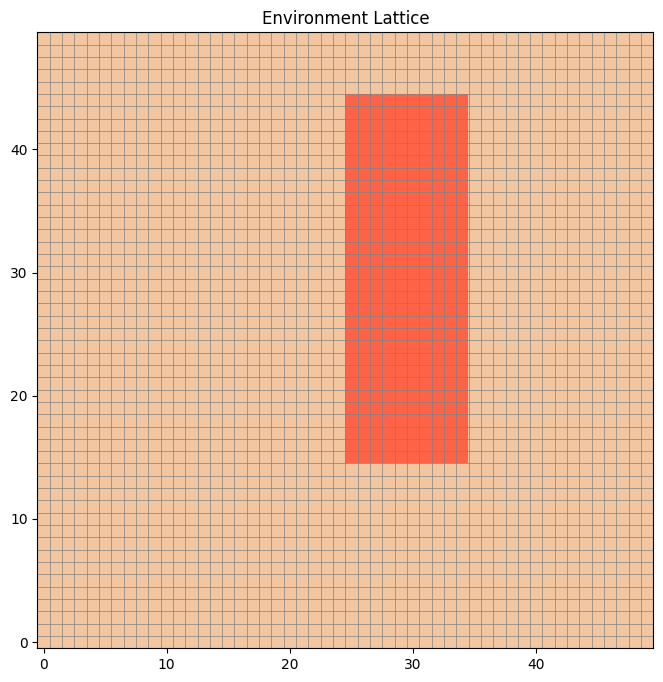

In [235]:

# custom colours: [wound, healthy]
cmap = ListedColormap(['tomato', '#f2c6a0'])  # skin-like tone

fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(lattice, cmap=cmap, origin='lower', vmin=0, vmax=1)

# Major ticks (few, readable)
ax.set_xticks(np.arange(0, Nx, 10))
ax.set_yticks(np.arange(0, Ny, 10))

# Minor ticks (for full grid)
ax.set_xticks(np.arange(-.5, Nx, 1), minor=True)
ax.set_yticks(np.arange(-.5, Ny, 1), minor=True)

# Grid on minor ticks
ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)

# Hide minor tick marks
ax.tick_params(which='minor', bottom=False, left=False)

plt.title("Environment Lattice")
plt.show()

#### Rules and regulations for healthy cells (agents) movement and reproduction

In [236]:
### a matrix to store the age of cells, which will be used to determine when they divide
cell_age = np.zeros((Nx, Ny), dtype=int)

In [237]:
### identify the neigbouring cells of a cell, which will be used to determine where a cell can divide into or move into
def neighbours(x,y):
    for i in [-1,0,1]: ## going down one step, staying in the same row, or going up one step
        for j in [-1,0,1]: ## going left one step, staying in the same column, or going right one step
            if (i,j) != (0,0):  # exclude the cell itself
                if 0 <= x+i < Nx and 0 <= y+j < Ny:  # check if within bounds
                    yield (x+i, y+j)    

In [238]:
### parameters for the model
prob_move = 0.5  # probability of healthy cells moving to wounded area
division_age = 2  # healthy cells divide when they are 3 time steps old
prob_reproduce = 0.2 # probability of cell reproduction when division age is reached
max_time = 20  # run the simulation for 20 time steps


In [239]:
### sequence for updating the cell status healthy or wounded, and the age of the cells
def update_lattice(lattice, cell_age):
    new_lattice = lattice.copy()
    new_cell_age = cell_age.copy()

    cells = [(x, y) for x in range(Nx) for y in range(Ny) if lattice[x, y] == 1] ## list of coordinates of healthy cells
    random.shuffle(cells) ## randomise the order of cell updates to avoid bias

    claimed_targets = set() ## to track which empty cells have already been claimed for movement or division

    for x, y in cells:
        if new_lattice[x, y] == 0: ## if the cell status is wounded (0), it cannot move or divide, so just continue to the next cell
            continue

        neigh = list(neighbours(x, y)) ## get the coordinates of neighbouring cells
        empty_neigh = [(nx, ny) for nx, ny in neigh if new_lattice[nx, ny] == 0] ## filter to get only the empty neighbouring cells

        if not empty_neigh: ## if there are no empty neighbouring cells, the cell cannot move or divide, so just age it
            new_cell_age[x, y] += 1
            continue

        moved = False 

        if np.random.rand() < prob_move:
            candidates = [(nx, ny) for nx, ny in empty_neigh if (nx, ny) not in claimed_targets] ## filter to get only the empty neighbouring cells that haven't been claimed for movement or division
            if candidates:
                nx, ny = random.choice(candidates) ## randomly select one of the available empty neighbouring cells to move into
                new_lattice[nx, ny] = 1 ## move the cell to the new location
                new_lattice[x, y] = 0 ## set the old location to empty
                new_cell_age[nx, ny] = cell_age[x, y] + 1 ## increment the age of the cell as it moves
                new_cell_age[x, y] = 0 ## reset the age of the old location since it's now empty
                claimed_targets.add((nx, ny)) ## mark the new location as claimed to prevent other cells from moving or dividing into it in the same time step
                moved = True

        if moved: ## if the cell has already moved, it cannot divide in the same time step, so skip to the next cell
            continue

        if cell_age[x, y] >= division_age and np.random.rand() < prob_reproduce: ## if the cell is old enough to divide and passes the reproduction probability check
            candidates = [(nx, ny) for nx, ny in empty_neigh if (nx, ny) not in claimed_targets] ## filter to get only the empty neighbouring cells that haven't been claimed for movement or division
            if candidates:
                nx, ny = random.choice(candidates) ## randomly select one of the available empty neighbouring cells to divide into
                new_lattice[nx, ny] = 1 ## place a new cell in the new location
                new_cell_age[nx, ny] = 0 ## set the age of the new cell to 0
                claimed_targets.add((nx, ny)) ## mark the new location as claimed to prevent other cells from moving or dividing into it in the same time step

        new_cell_age[x, y] += 1 ## increment the age of the cell at the end of the time step (after potential movement and division)

    return new_lattice, new_cell_age

#### Simulation and visualization

In [240]:
lattice_ls = [lattice.copy()]
cell_age_ls = [cell_age.copy()]
for t in range(max_time):
    new_lattice, new_cell_age = update_lattice(lattice_ls[-1], cell_age_ls[-1])
    lattice_ls.append(new_lattice)
    cell_age_ls.append(new_cell_age)


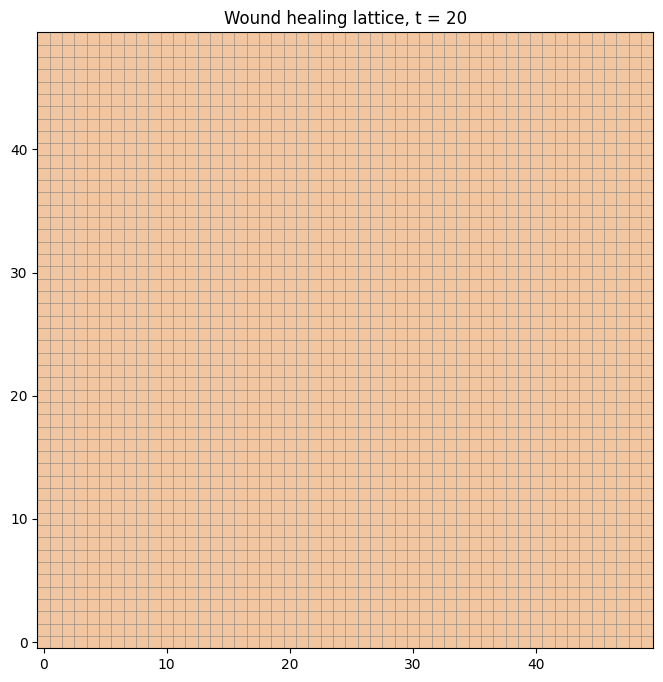

In [241]:
# custom colours: [wound, healthy]
cmap = ListedColormap(['tomato', '#f2c6a0'])

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(lattice_ls[0], cmap=cmap, origin='lower', vmin=0, vmax=1, animated=True)

# Major ticks
ax.set_xticks(np.arange(0, Nx, 10))
ax.set_yticks(np.arange(0, Ny, 10))

# Minor ticks for cell grid
ax.set_xticks(np.arange(-0.5, Nx, 1), minor=True)
ax.set_yticks(np.arange(-0.5, Ny, 1), minor=True)
ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.4)
ax.tick_params(which='minor', bottom=False, left=False)

title = ax.set_title("Environment Lattice, t = 0")

def animate(frame):
    im.set_data(lattice_ls[frame])
    title.set_text(f"Wound healing lattice, t = {frame}")
    return [im, title]

ani = FuncAnimation(
    fig,
    animate,
    frames=len(lattice_ls),
    interval=200,
    blit=True,
    repeat=False
)

ani.save("wound_healing.gif", writer=PillowWriter(fps=5))


Below is a animation of how wound is healing.

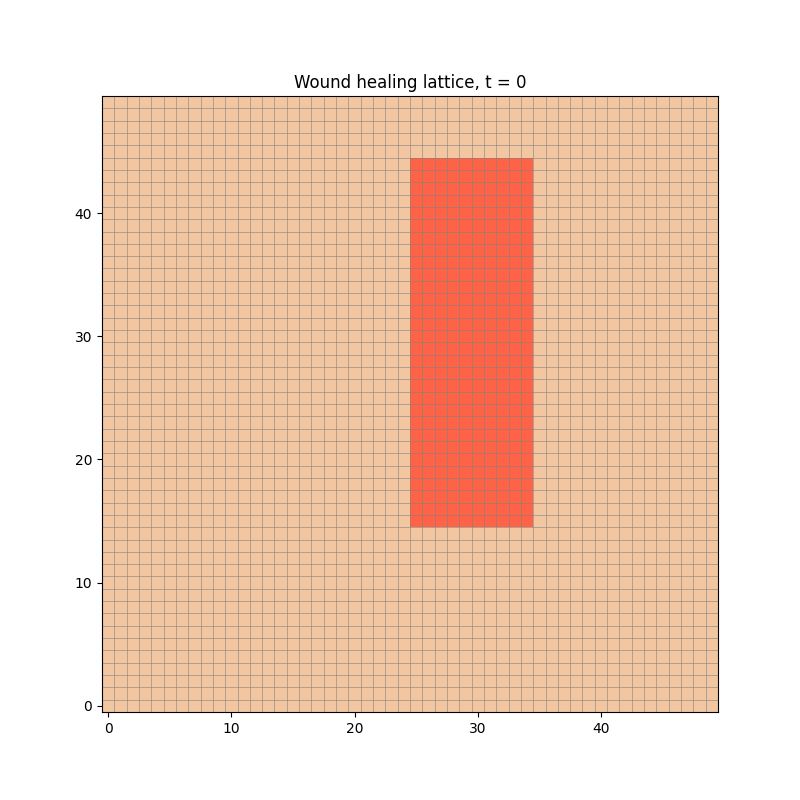

Notice some flaws in the wound healing process in the animation:
- scattered healing unlike what we see in reality, where a front of cells move in to fill the wound, and 
- cells are moving to heal the wound and leaving blank spot behind them.

Reason being the over simplification of the wound healing process, which I did to make a toy model to start with. Next, we will add more biological information to make it a bit more close to reality.

**Note:** In research, we start with toy versions of any problem to get our head around it and systematically add complexities, which allows us to select the ones that significanly impact the dynamics and makes the model closer to real phenomenon.

### Improved model

We will add more restriction to the movement of healthy agents based on the biological information that cells collectively move as a front to heal the wound. In the improved version, we focus on moving the cells near to the wound to move in as front and other healthy cells follow them instantly, thus won't leave spaces behind them. This logic is based on the intuition that in reality, mechanical forces are present between the cells (cohesion and adhesion), which helps them in moving collectively without getting detached from the other healthy cells.  

Let's code it!

In [228]:
## defining the environment and agents (cells) status healthy or wounded and cell age, which will be used to determine when they divide
Nx, Ny = 50, 50

lattice = np.ones((Nx, Ny), dtype=int)

wound_x = np.arange(15, 45)
wound_y = np.arange(25, 35)

for x in wound_x:
    for y in wound_y:
        lattice[x, y] = 0

initial_wound_mask = (lattice == 0)
cell_age = np.zeros((Nx, Ny), dtype=int)

## parameter for simulation
prob_move = 0.5
prob_reproduce = 0.2
division_age = 2
max_time = 20

In [229]:
### Improved sequence of update to mimic the front movement healing process
def update_lattice_collective(lattice, cell_age, initial_wound_mask):
    new_lattice = lattice.copy()
    new_cell_age = cell_age.copy()

    ## identify the columns that contain the wound area
    wound_columns = np.where(np.any(initial_wound_mask, axis=1))[0]

    ## loop over wounded cells instead of healthy cells
    for x in wound_columns:
        ## identify the rows in the current column that are wounded
        wound_rows = np.where(initial_wound_mask[x, :])[0]
        if len(wound_rows) == 0:
            continue

        y_min = wound_rows.min()
        y_max = wound_rows.max()

        ## if wound is healed in this column, skip to the next column
        current_gap = np.where(new_lattice[x, y_min:y_max+1] == 0)[0]
        if len(current_gap) == 0:
            continue

        gap_rows = current_gap + y_min
        top_gap = gap_rows.min()
        bottom_gap = gap_rows.max()

        # upper front moves downward, healthy cells moving in from right hand side to fill the gap
        if top_gap - 1 >= 0 and new_lattice[x, top_gap - 1] == 1:
            if np.random.rand() < prob_move:
                new_lattice[x, top_gap] = 1
                new_cell_age[x, top_gap] = new_cell_age[x, top_gap - 1] + 1

        # lower front moves upward, healthy cells moving in from left hand side to fill the gap
        if bottom_gap + 1 < Ny and new_lattice[x, bottom_gap + 1] == 1:
            if np.random.rand() < prob_move:
                new_lattice[x, bottom_gap] = 1
                new_cell_age[x, bottom_gap] = new_cell_age[x, bottom_gap + 1] + 1

        # delayed reproduction as occurs after movement, which allows for redensification of the cell population in the wounded area
        remaining_gap = np.where(new_lattice[x, y_min:y_max+1] == 0)[0]
        if prob_reproduce > 0 and len(remaining_gap) > 0:
            gap_rows = remaining_gap + y_min

            for y in gap_rows:
                neigh = []
                if y - 1 >= 0 and new_lattice[x, y - 1] == 1:
                    neigh.append((x, y - 1))
                if y + 1 < Ny and new_lattice[x, y + 1] == 1:
                    neigh.append((x, y + 1))

                if neigh:
                    px, py = random.choice(neigh)
                    if new_cell_age[px, py] >= division_age and np.random.rand() < prob_reproduce:
                        new_lattice[x, y] = 1
                        new_cell_age[x, y] = 0

    new_cell_age[new_lattice == 1] += 1
    new_cell_age[new_lattice == 0] = 0

    return new_lattice, new_cell_age

In [230]:
lattice_ls = [lattice.copy()]
cell_age_ls = [cell_age.copy()]
initial_wound_mask = (lattice == 0)

for t in range(max_time):
    new_lattice, new_cell_age = update_lattice_collective(lattice_ls[-1],cell_age_ls[-1],initial_wound_mask)
    lattice_ls.append(new_lattice)
    cell_age_ls.append(new_cell_age)

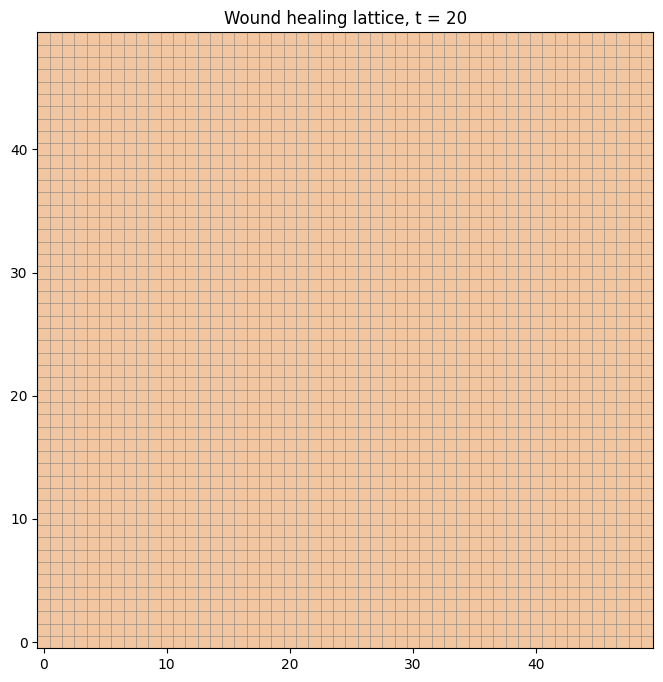

In [231]:
# custom colours: [wound, healthy]
cmap = ListedColormap(['tomato', '#f2c6a0'])

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(lattice_ls[0], cmap=cmap, origin='lower', vmin=0, vmax=1, animated=True)

# Major ticks
ax.set_xticks(np.arange(0, Nx, 10))
ax.set_yticks(np.arange(0, Ny, 10))

# Minor ticks for cell grid
ax.set_xticks(np.arange(-0.5, Nx, 1), minor=True)
ax.set_yticks(np.arange(-0.5, Ny, 1), minor=True)
ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.4)
ax.tick_params(which='minor', bottom=False, left=False)

title = ax.set_title("Environment Lattice, t = 0")

def animate(frame):
    im.set_data(lattice_ls[frame])
    title.set_text(f"Wound healing lattice, t = {frame}")
    return [im, title]

ani = FuncAnimation(
    fig,
    animate,
    frames=len(lattice_ls),
    interval=200,
    blit=True,
    repeat=False
)

ani.save("wound_healing_improved.gif", writer=PillowWriter(fps=5))


Below is the animation of wound healing, in which cells move as collective front, more closer to real phenomenon.

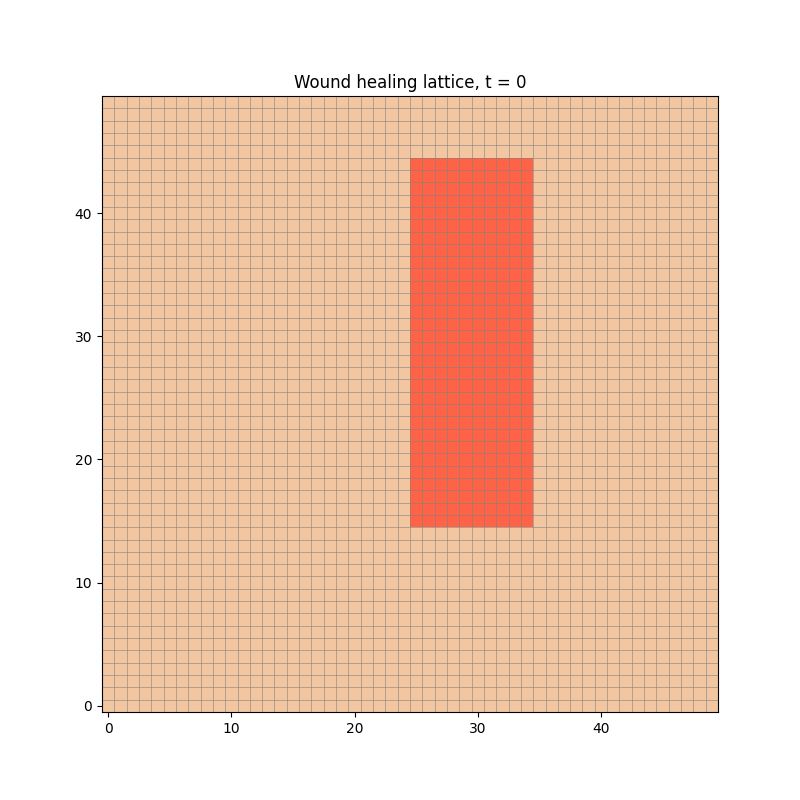
